**Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedKFold

**Initial Analysis**

In [3]:
TRAIN_PATH = "data/raw/application_train.csv"
TEST_PATH = "data/raw/application_test.csv"

In [4]:
def initial_data_inspection(train_path, test_path):
    print("Loading datasets...")
    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)

    print(f"Train shape: {df_train.shape}")
    print(f"Test shape: {df_test.shape}")

    # 1. Target distribution check
    if 'TARGET' in df_train.columns:
        target_counts = df_train['TARGET'].value_counts(normalize=True) * 100
        print("\nTarget Distribution (%):")
        print(target_counts)
    else:
        print("\nError: TARGET column missing from training data.")

    # 2. Missing value quantification
    missing_train = df_train.isnull().sum()
    missing_pct = (missing_train / len(df_train)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing_train, 'Missing %': missing_pct})
    missing_df = missing_df[missing_df['Missing %'] > 0].sort_values(by='Missing %', ascending=False)

    print(f"\nColumns with missing values: {len(missing_df)} out of {df_train.shape[1]}")
    print("\nTop 15 columns with highest missing percentages:")
    print(missing_df.head(15))

    # 3. Data types overview
    print("\nFeature Data Types:")
    print(df_train.dtypes.value_counts())

    return df_train, df_test


if __name__ == "__main__":
    df_train, df_test = initial_data_inspection(TRAIN_PATH, TEST_PATH)

Loading datasets...
Train shape: (307511, 122)
Test shape: (48744, 121)

Target Distribution (%):
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

Columns with missing values: 67 out of 122

Top 15 columns with highest missing percentages:
                          Missing Count  Missing %
COMMONAREA_MEDI                  214865  69.872297
COMMONAREA_AVG                   214865  69.872297
COMMONAREA_MODE                  214865  69.872297
NONLIVINGAPARTMENTS_MEDI         213514  69.432963
NONLIVINGAPARTMENTS_MODE         213514  69.432963
NONLIVINGAPARTMENTS_AVG          213514  69.432963
FONDKAPREMONT_MODE               210295  68.386172
LIVINGAPARTMENTS_MODE            210199  68.354953
LIVINGAPARTMENTS_MEDI            210199  68.354953
LIVINGAPARTMENTS_AVG             210199  68.354953
FLOORSMIN_MODE                   208642  67.848630
FLOORSMIN_MEDI                   208642  67.848630
FLOORSMIN_AVG                    208642  67.848630
YEARS_BUILD_MODE        

--- Time Variables Summary Statistics ---
          DAYS_BIRTH  DAYS_EMPLOYED  DAYS_REGISTRATION
count  307511.000000  307511.000000      307511.000000
mean   -16036.995067   63815.045904       -4986.120328
std      4363.988632  141275.766519        3522.886321
min    -25229.000000  -17912.000000      -24672.000000
25%    -19682.000000   -2760.000000       -7479.500000
50%    -15750.000000   -1213.000000       -4504.000000
75%    -12413.000000    -289.000000       -2010.000000
max     -7489.000000  365243.000000           0.000000


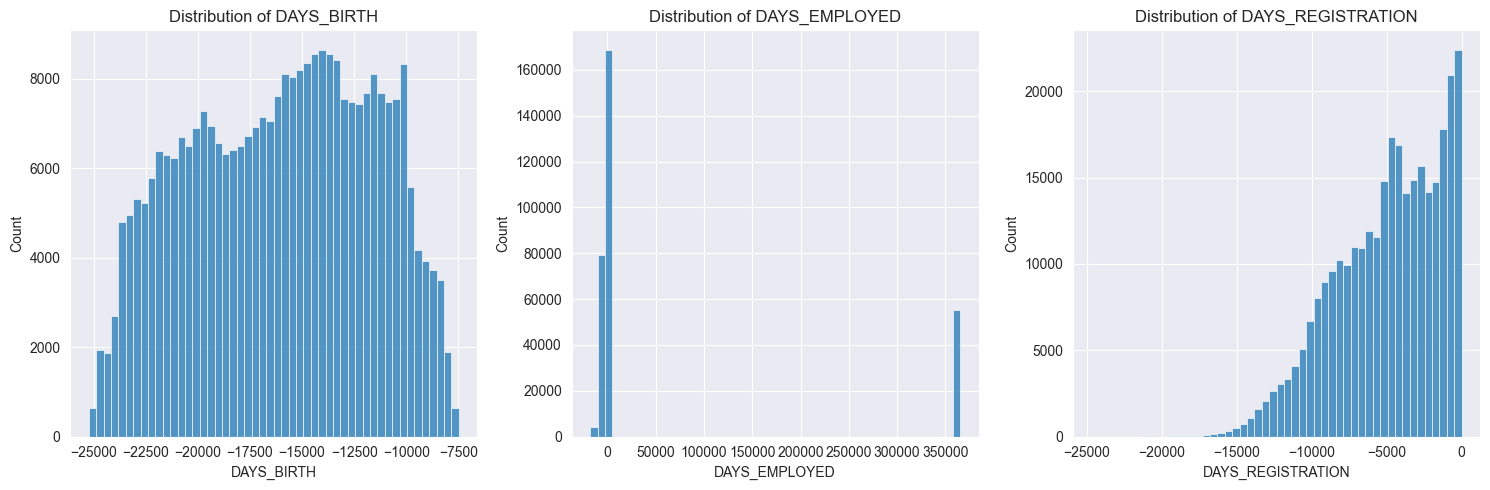


--- Categorical Feature Cardinality ---
ORGANIZATION_TYPE             58
OCCUPATION_TYPE               18
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                7
WEEKDAY_APPR_PROCESS_START     7
WALLSMATERIAL_MODE             7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             4
CODE_GENDER                    3
HOUSETYPE_MODE                 3
NAME_CONTRACT_TYPE             2
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2
dtype: int64


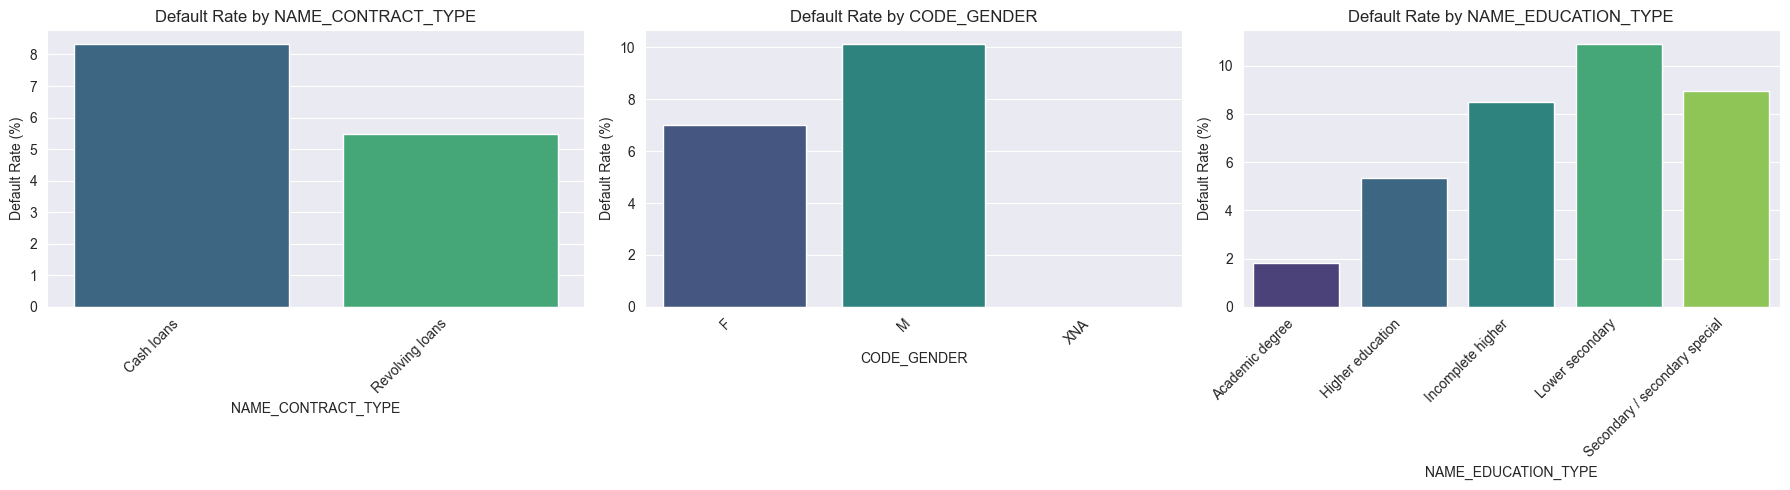

In [5]:
time_cols = ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION']
print("--- Time Variables Summary Statistics ---")
print(df_train[time_cols].describe())

plt.figure(figsize=(15, 5))
for i, col in enumerate(time_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df_train[col].dropna(), bins=50, kde=False)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

print("\n--- Categorical Feature Cardinality ---")
cat_cols = df_train.select_dtypes(include=['object']).columns
cardinality = df_train[cat_cols].nunique().sort_values(ascending=False)
print(cardinality)

bivariate_cols = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_EDUCATION_TYPE']
plt.figure(figsize=(18, 5))
for i, col in enumerate(bivariate_cols, 1):
    plt.subplot(1, 3, i)
    default_rate = df_train.groupby(col)['TARGET'].mean() * 100
    sns.barplot(x=default_rate.index, y=default_rate.values, hue=default_rate.index, palette="viridis", legend=False)
    plt.title(f'Default Rate by {col}')
    plt.ylabel('Default Rate (%)')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
X_adv_train = df_train.drop(columns=['TARGET']).copy()
X_adv_train['is_test'] = 0

X_adv_test = df_test.copy()
X_adv_test['is_test'] = 1

df_adv = pd.concat([X_adv_train, X_adv_test], ignore_index=True)

df_adv['DAYS_EMPLOYED_ANOMALY'] = (df_adv['DAYS_EMPLOYED'] == 365243).astype(int)
df_adv['DAYS_EMPLOYED'] = df_adv['DAYS_EMPLOYED'].replace(365243, np.nan)
df_adv['DAYS_EMPLOYED'] = df_adv['DAYS_EMPLOYED'] / -365.25

num_cols = df_adv.select_dtypes(include=['int64', 'float64']).columns.drop(['is_test', 'SK_ID_CURR'])

X_adv = df_adv[num_cols]
y_adv = df_adv['is_test']

adv_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

print("Running adversarial validation (this may take a minute)...")
cv_scores = cross_val_score(adv_pipeline, X_adv, y_adv, cv=3, scoring='roc_auc')

print(f"Adversarial ROC AUC scores across folds: {cv_scores}")
print(f"Mean Adversarial ROC AUC: {np.mean(cv_scores):.4f}")

Running adversarial validation (this may take a minute)...
Adversarial ROC AUC scores across folds: [0.78061873 0.78292773 0.78096483]
Mean Adversarial ROC AUC: 0.7815


/var/folders/v0/d2kg07156rqgnbhjky9fq9pw0000gn/T/ipykernel_65847/73642054.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=drift_df.head(15), palette='coolwarm')


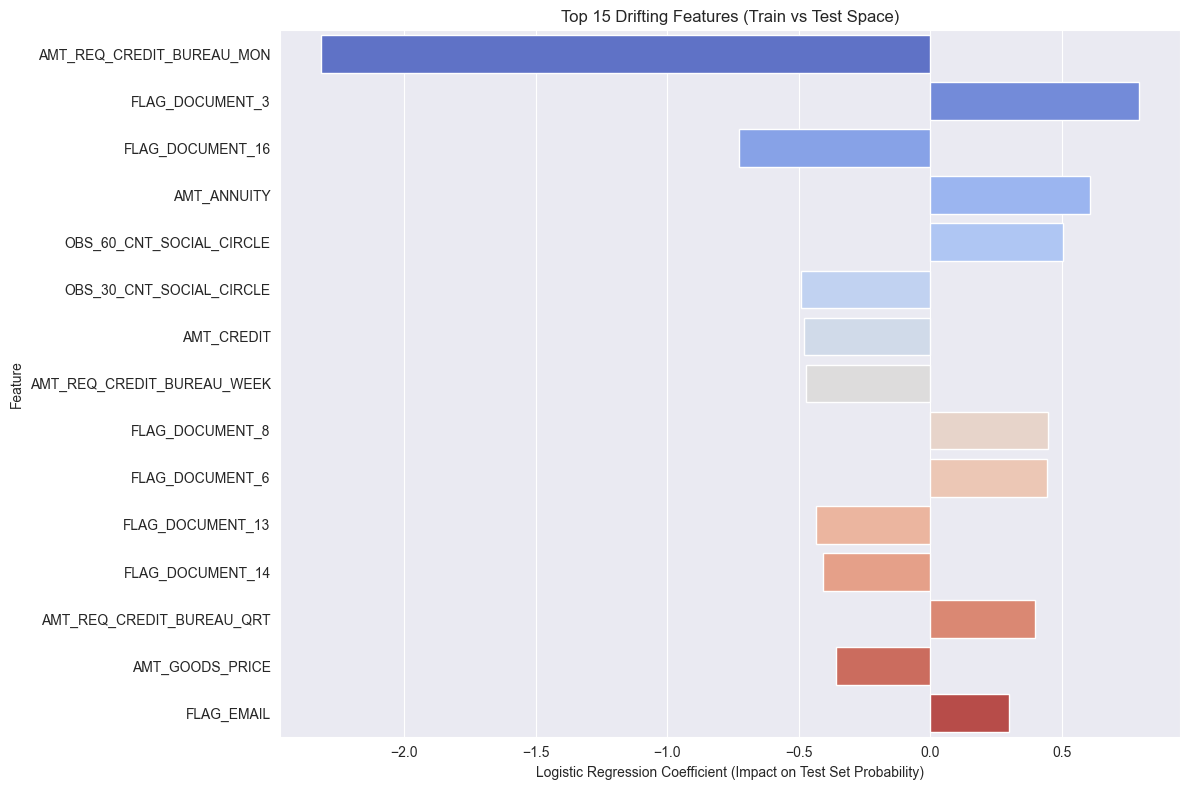

--- Top 15 Most Unstable Features ---
                   Feature  Coefficient
 AMT_REQ_CREDIT_BUREAU_MON    -2.315708
           FLAG_DOCUMENT_3     0.794794
          FLAG_DOCUMENT_16    -0.726315
               AMT_ANNUITY     0.607428
  OBS_60_CNT_SOCIAL_CIRCLE     0.507242
  OBS_30_CNT_SOCIAL_CIRCLE    -0.491247
                AMT_CREDIT    -0.480337
AMT_REQ_CREDIT_BUREAU_WEEK    -0.473627
           FLAG_DOCUMENT_8     0.449853
           FLAG_DOCUMENT_6     0.444946
          FLAG_DOCUMENT_13    -0.434354
          FLAG_DOCUMENT_14    -0.408780
 AMT_REQ_CREDIT_BUREAU_QRT     0.400333
           AMT_GOODS_PRICE    -0.358821
                FLAG_EMAIL     0.298235


In [9]:
clf = adv_pipeline.named_steps['clf']

feature_names = num_cols

adv_pipeline.fit(X_adv, y_adv)

coefs = clf.coef_[0]

drift_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
drift_df['Absolute_Importance'] = drift_df['Coefficient'].abs()
drift_df = drift_df.sort_values(by='Absolute_Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', data=drift_df.head(15), palette='coolwarm')
plt.title('Top 15 Drifting Features (Train vs Test Space)')
plt.xlabel('Logistic Regression Coefficient (Impact on Test Set Probability)')
plt.tight_layout()
plt.show()

print("--- Top 15 Most Unstable Features ---")
print(drift_df[['Feature', 'Coefficient']].head(15).to_string(index=False))

In [10]:
def get_high_correlation_pairs(df, threshold = 0.95):
    num_df = df.select_dtypes(include=['number'])
    
    cols_to_drop = [c for c in ['SK_ID_CURR', 'TARGET'] if c in num_df.columns]
    num_df = num_df.drop(columns=cols_to_drop, errors='ignore')

    corr_matrix = num_df.corr()

    mask = np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)
    
    pairs = corr_matrix.where(mask).stack().reset_index()
    pairs.columns = ['f_1', 'f_2', 'correlation']

    pairs['abs_correlation'] = pairs['correlation'].abs()
    high_corr_df = pairs[pairs['abs_correlation'] > threshold].sort_values(
        by='abs_correlation', ascending=False
    ).reset_index(drop=True)

    return high_corr_df

In [11]:
train_eng = df_train.copy()
test_eng = df_test.copy()

drift_features = [
    'AMT_REQ_CREDIT_BUREAU_MON', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_16', 
    'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14'
]
train_eng = train_eng.drop(columns=drift_features, errors='ignore')
test_eng = test_eng.drop(columns=drift_features, errors='ignore')

for df in [train_eng, test_eng]:
    df['DAYS_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan) / -365.25
    df['DAYS_BIRTH'] = df['DAYS_BIRTH'] / -365.25
    df['DAYS_REGISTRATION'] = df['DAYS_REGISTRATION'] / -365.25
    
    df['CREDIT_TO_ANNUITY_RATIO'] = df['AMT_CREDIT'] / df['AMT_ANNUITY']
    df['INCOME_PER_CAPITA'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']

high_corr_df = get_high_correlation_pairs(train_eng, threshold=0.95)
print("--- Highly Correlated Pairs Identified ---")
print(high_corr_df.to_string())

features_to_drop = [
    'FLAG_EMP_PHONE', 'AMT_GOODS_PRICE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'REGION_RATING_CLIENT_W_CITY',
    'YEARS_BUILD_MEDI', 'FLOORSMIN_MEDI', 'FLOORSMAX_MEDI', 'ENTRANCES_MEDI',
    'ELEVATORS_MEDI', 'COMMONAREA_MEDI', 'LIVINGAREA_MEDI', 'APARTMENTS_MEDI',
    'BASEMENTAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI',
    'LANDAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'YEARS_BUILD_MODE',
    'FLOORSMIN_MODE', 'FLOORSMAX_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'COMMONAREA_MODE',
    'LANDAREA_MODE', 'BASEMENTAREA_MODE', 'APARTMENTS_MODE', 'LIVINGAREA_MODE',
    'YEARS_BEGINEXPLUATATION_MODE', 'LIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MODE',
    'NONLIVINGAREA_MODE'
]

print(f"\nDropping {len(features_to_drop)} collinear features: {features_to_drop}")

train_eng = train_eng.drop(columns=features_to_drop, errors='ignore')
test_eng = test_eng.drop(columns=features_to_drop, errors='ignore')

cat_cols = train_eng.select_dtypes(include=['object']).columns
for df in [train_eng, test_eng]:
    df[cat_cols] = df[cat_cols].astype('category')

print(f"\nFinal Preprocessed Train Shape: {train_eng.shape}")
print(f"Final Preprocessed Test Shape: {test_eng.shape}")

--- Highly Correlated Pairs Identified ---
                             f_1                           f_2  correlation  abs_correlation
0                 FLAG_EMP_PHONE         DAYS_EMPLOYED_ANOMALY    -0.999868         0.999868
1                YEARS_BUILD_AVG              YEARS_BUILD_MEDI     0.998495         0.998495
2       OBS_30_CNT_SOCIAL_CIRCLE      OBS_60_CNT_SOCIAL_CIRCLE     0.998490         0.998490
3                  FLOORSMIN_AVG                FLOORSMIN_MEDI     0.997241         0.997241
4                  FLOORSMAX_AVG                FLOORSMAX_MEDI     0.997034         0.997034
5                  ENTRANCES_AVG                ENTRANCES_MEDI     0.996886         0.996886
6                  ELEVATORS_AVG                ELEVATORS_MEDI     0.996099         0.996099
7                 COMMONAREA_AVG               COMMONAREA_MEDI     0.995978         0.995978
8                 LIVINGAREA_AVG               LIVINGAREA_MEDI     0.995596         0.995596
9                 APARTMENT

In [12]:
train_eng.to_parquet('data/clean/train_eng.parquet', index=False)
test_eng.to_parquet('data/clean/test_eng.parquet', index=False)

print("Data successfully serialized to data/clean/ in Parquet format.")

Data successfully serialized to data/clean/ in Parquet format.
